# 05 · 잉여금 최적화 — 헤지 블록(LHP)과 수익 추구 블록(PSP)

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M7_%EC%8B%A4%EC%8A%B5_Colab/05_%EC%9E%89%EC%97%AC%EA%B8%88%EC%B5%9C%EC%A0%81%ED%99%94_%EB%91%90%EB%B8%94%EB%A1%9D.ipynb)

**W06 M7 LDI 강의본 단원 ⑤(45~49장)** 와 51장 각주를 재현합니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 목적식 · 선택 변수 · 제약 | 46장 | max E[R_S] − (γ/2)Var(R_S), R_S = r_A − (L/A)r_L · 제약은 비중의 합 = 1뿐 |
| 해 = PSP + LHP | 47장 | 주식 4% ÷ (3.6 × 0.15²) = 49% · 30년 국채 (1 ÷ 1.25)(20 ÷ 20) = 80% · 합 130% → 모자란 30%는 스왑 |
| 실무적 함의 | 48장 | 헤지 몫에는 μ도 γ도 없다 · 주식 50%의 잉여금 변동성: 헤지 19% → 12.8%, 헤지 100% → 7.5% |
| 적립비율과 헤지 비중 | 49 · 51장 | 헤지 비중 = D_L·L ÷ (D_H·A): FR 125% → 80/20 · 120% → 83/17 · 80% → 필요 125% → 상한 100% |

**가정(한 요인 모형)**: 주식 기대초과수익 4% · 변동성 15%(금리와 무상관, 듀레이션 0), 30년 국채 D_H = 20(초과수익 0), 부채 D_L = 20, A = 100 · L = 80, 위험회피 γ = 3.6.
48장의 잉여금 변동성은 강의본에 적히지 않은 **금리 변동성 0.8%p**를 씁니다(출처: 보충교재 17 `LDI/02_LDI_Derivations_II` 6-1절 — 이 값으로 12.8% · 7.5%가 그대로 나옴).

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
가정을 바꿔 실험할 때는 `FAST = True`로 두면 확인이 멈추지 않고 ✗로 표시만 합니다(M7 세트는 계산이 가벼워 속도 차이는 없음).

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — M7 세트는 계산이 가벼워 FAST가 결과를 바꾸지 않는다. True면 확인(check)이 멈추지 않고 표시만 한다(숫자를 바꿔 실험할 때)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 문제 — 목적 · 선택 변수 · 제약 (강의 46장)
Sharpe–Tint(1990) 잉여금 평균–분산.
- 목적: **max_w E[R_S] − (γ/2)·Var(R_S)**, R_S = r_A − (L/A)·r_L, r_A = Σ w_i r_i
- 선택 변수: 자산 비중 w (주식 · 30년 국채 · 현금)
- 제약: 비중의 합 = 1뿐 — **듀레이션 매칭은 제약이 아니라 해**

한 요인 모형에서 금리 변화를 Δy(변동성 σ_y)라 하면 30년 국채의 초과수익 = −D_H·Δy, 부채 수익(현금 대비) = −D_L·Δy.

In [2]:
mu_e, sig_e = 0.04, 0.15         # 주식 기대초과수익 · 변동성
gamma = 3.6                      # 위험회피
D_H, D_L = 20.0, 20.0            # 30년 국채 · 부채 듀레이션
A, L = 100.0, 80.0
FR = A / L
sig_y = 0.008                    # 금리 변동성 0.8%p (보충교재 도출 II 6-1 — 48장 잉여금 변동성용)

def surplus_moments(w_e, w_h, sig_y=sig_y):
    """현금 대비 잉여금 수익률의 평균 · 분산 — 주식 w_e, 30년 국채 w_h (나머지 현금)"""
    mean = w_e * mu_e                                   # 국채 · 부채의 초과수익 0
    rate_exposure = w_h * D_H - D_L / FR                # Δy 한 단위에 대한 잉여금 노출(자산 대비)
    var = (w_e * sig_e) ** 2 + (rate_exposure * sig_y) ** 2
    return mean, var

print(f"FR = {FR:.0%} · L/A = {1 / FR:.2f}")

FR = 125% · L/A = 0.80


## 2. 해 — 최적 비중 = 투기적 수요(PSP) + 헤지 수요(LHP) (강의 47장)
1계 조건을 풀면 **w_i\* = μ_i ÷ (γσ_i²) + (1/FR) · Cov(r_i, r_L) ÷ σ_i²**.
한 요인 모형이면 헤지 몫은 **w_H\* = (1/FR) · (D_L/D_H)** ⇔ w_H\*·A·D_H = L·D_L (DV01 매칭).

In [3]:
w_psp = mu_e / (gamma * sig_e**2)
w_lhp = (1 / FR) * (D_L / D_H)
print(f"주식 (PSP) = 4% ÷ (3.6 × 0.15²) = {w_psp:.1%} ≈ 50%")
print(f"30년 국채 (LHP) = (1 ÷ {FR:.2f}) × ({D_H:.0f} ÷ {D_L:.0f}) = {w_lhp:.0%}")
psp_r = round(w_psp * 10) / 10                     # 강의는 49% ≈ 50%로 반올림해 합을 적는다
print(f"합계 {psp_r:.0%} + {w_lhp:.0%} = {psp_r + w_lhp:.0%} (반올림 전 {w_psp + w_lhp:.1%}) → 100%를 넘는 {psp_r + w_lhp - 1:.0%}는 고정금리 수취 스왑으로")
print(f"검산: 헤지 몫 {w_lhp:.0%} × D_H {D_H:.0f} × A {A:.0f} = {w_lhp * D_H * A:.0f} = 부채 {L:.0f} × D_L {D_L:.0f} = {L * D_L:.0f}")
check("PSP 주식 비중 (%)", 100 * w_psp, 49, 0.5, ".2f")
check("LHP 30년 국채 비중 (%)", 100 * w_lhp, 80, 0.5, ".1f")
check("합계 — PSP 50% 반올림 (%)", 100 * (psp_r + w_lhp), 130, 0.5, ".1f")

주식 (PSP) = 4% ÷ (3.6 × 0.15²) = 49.4% ≈ 50%
30년 국채 (LHP) = (1 ÷ 1.25) × (20 ÷ 20) = 80%
합계 50% + 80% = 130% (반올림 전 129.4%) → 100%를 넘는 30%는 고정금리 수취 스왑으로
검산: 헤지 몫 80% × D_H 20 × A 100 = 1600 = 부채 80 × D_L 20 = 1600
✓ PSP 주식 비중 (%): 계산 49.38 · 강의 49.00 (허용 ±0.5)
✓ LHP 30년 국채 비중 (%): 계산 80.0 · 강의 80.0 (허용 ±0.5)
✓ 합계 — PSP 50% 반올림 (%): 계산 130.0 · 강의 130.0 (허용 ±0.5)


**수치 확인 — 닫힌 해가 정말 최적인가?** scipy로 목적식을 직접 최대화합니다(주식 · 30년 국채 비중을 자유롭게, 현금이 나머지).
γ를 바꿔도 헤지 몫이 그대로인지(48장 함의 ①)도 봅니다.

In [4]:
from scipy.optimize import minimize
def solve(gamma_, sig_y_=sig_y):
    obj = lambda w: -(surplus_moments(w[0], w[1], sig_y_)[0] - 0.5 * gamma_ * surplus_moments(w[0], w[1], sig_y_)[1])
    return minimize(obj, x0=[0.3, 0.3], method="BFGS").x

print(f"{'γ':>5s} {'주식':>8s} {'30년 국채':>10s}")
for g in [2.0, 3.6, 8.0]:
    we, wh = solve(g)
    print(f"{g:5.1f} {we:8.1%} {wh:10.1%}")
we, wh = solve(gamma)
check("수치 최적 주식 = 닫힌 해", we, w_psp, 1e-4)
check("수치 최적 국채 = 닫힌 해", wh, w_lhp, 1e-4)
for g in [2.0, 8.0]:
    check(f"γ = {g}에서도 헤지 몫 80%", solve(g)[1], w_lhp, 1e-4)

    γ       주식     30년 국채
  2.0    88.9%      80.0%
  3.6    49.4%      80.0%
  8.0    22.2%      80.0%
✓ 수치 최적 주식 = 닫힌 해: 계산 0.4938 · 강의 0.4938 (허용 ±0.0001)
✓ 수치 최적 국채 = 닫힌 해: 계산 0.8000 · 강의 0.8000 (허용 ±0.0001)
✓ γ = 2.0에서도 헤지 몫 80%: 계산 0.8000 · 강의 0.8000 (허용 ±0.0001)
✓ γ = 8.0에서도 헤지 몫 80%: 계산 0.8000 · 강의 0.8000 (허용 ±0.0001)


## 3. 남는 위험 예산만 수익 추구에 (강의 48장 ②)
주식 50%일 때 잉여금 변동성 = √[(0.5 × 15%)² + ((D_L/FR)·(1 − h)·σ_y)²], h = 헤지비율.
- 헤지 19%(03 노트북의 '지금', 자산 전부 D 3) → **12.8%**
- 헤지 100% → **7.5%** (주식 위험만 남음)

In [5]:
def surplus_vol(w_e, h, sig_y=sig_y):
    return math.sqrt((w_e * sig_e) ** 2 + ((D_L / FR) * (1 - h) * sig_y) ** 2)

h_now = 0.03 / 0.16
v19, v100 = surplus_vol(0.5, h_now), surplus_vol(0.5, 1.0)
print(f"금리 위험 계수 D_L/FR × σ_y = {D_L / FR:.0f} × 0.8%p = {D_L / FR * sig_y:.1%}")
print(f"주식 50% · 헤지 {h_now:.0%}: 잉여금 변동성 {v19:.1%} · 헤지 100%: {v100:.1%}")
check("헤지 19%의 잉여금 변동성 (%)", 100 * v19, 12.8, 0.05, ".2f")
check("헤지 100%의 잉여금 변동성 (%)", 100 * v100, 7.5, 0.05, ".2f")

금리 위험 계수 D_L/FR × σ_y = 16 × 0.8%p = 12.8%
주식 50% · 헤지 19%: 잉여금 변동성 12.8% · 헤지 100%: 7.5%
✓ 헤지 19%의 잉여금 변동성 (%): 계산 12.82 · 강의 12.80 (허용 ±0.05)
✓ 헤지 100%의 잉여금 변동성 (%): 계산 7.50 · 강의 7.50 (허용 ±0.05)


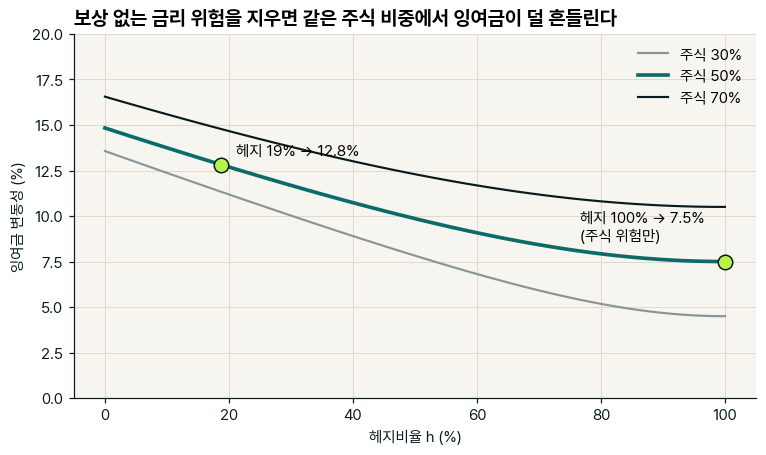

In [6]:
hs = np.linspace(0, 1, 101)
fig, ax = plt.subplots(figsize=(8, 4.3))
for w_e, c in [(0.3, GRAY), (0.5, TEAL), (0.7, INK)]:
    ax.plot(hs * 100, [100 * surplus_vol(w_e, h) for h in hs], color=c, lw=2.4 if w_e == 0.5 else 1.4, label=f"주식 {w_e:.0%}")
ax.scatter([h_now * 100, 100], [100 * v19, 100 * v100], s=90, color=LIME, edgecolor=INK, zorder=5)
ax.annotate(f"헤지 {h_now:.0%} → {v19:.1%}", (h_now * 100, 100 * v19), textcoords="offset points", xytext=(10, 6))
ax.annotate(f"헤지 100% → {v100:.1%}\n(주식 위험만)", (100, 100 * v100), textcoords="offset points", xytext=(-95, 14))
ax.set_xlabel("헤지비율 h (%)"); ax.set_ylabel("잉여금 변동성 (%)")
ax.set_title("보상 없는 금리 위험을 지우면 같은 주식 비중에서 잉여금이 덜 흔들린다")
ax.legend(); ax.set_ylim(0, 20)
plt.show()

## 4. 적립비율에 따른 헤지 비중 (강의 49장)
D_L = D_H = 20이면 헤지 비중 = D_L·L ÷ (D_H·A) = 1/FR. **적립이 부족할수록 헤지에 자금이 더 들고** 수익 추구 몫은 줄어듭니다.
레버리지 없이는 100%가 상한 — 모자란 헤지는 IRS로 채우고, 그만큼 증거금(레버리지)이 생깁니다.

In [7]:
CASES = [("FR 125% (A 100, L 80)", 100, 80, 80, 20), ("FR 120% (A 120, L 100)", 120, 100, 83, 17), ("FR 80% (A 80, L 100)", 80, 100, 100, 0)]
for name, A_, L_, lec_h, lec_rs in CASES:
    need = D_L * L_ / (D_H * A_)
    hedge = min(need, 1.0)
    print(f"{name:24s} 필요 헤지 {need:5.1%} → 헤지 {hedge:4.0%} · 수익 추구 {1 - hedge:4.0%}" + ("  ← 상한 100%" if need > 1 else ""))
    check(f"{name} 헤지 (%)", 100 * hedge, lec_h, 0.5, ".1f")
    check(f"{name} 수익 추구 (%)", 100 * (1 - hedge), lec_rs, 0.5, ".1f")
check("FR 80% 필요 헤지 (%)", 100 * D_L * 100 / (D_H * 80), 125, 0.5, ".1f")

FR 125% (A 100, L 80)    필요 헤지 80.0% → 헤지  80% · 수익 추구  20%
✓ FR 125% (A 100, L 80) 헤지 (%): 계산 80.0 · 강의 80.0 (허용 ±0.5)
✓ FR 125% (A 100, L 80) 수익 추구 (%): 계산 20.0 · 강의 20.0 (허용 ±0.5)
FR 120% (A 120, L 100)   필요 헤지 83.3% → 헤지  83% · 수익 추구  17%
✓ FR 120% (A 120, L 100) 헤지 (%): 계산 83.3 · 강의 83.0 (허용 ±0.5)
✓ FR 120% (A 120, L 100) 수익 추구 (%): 계산 16.7 · 강의 17.0 (허용 ±0.5)
FR 80% (A 80, L 100)     필요 헤지 125.0% → 헤지 100% · 수익 추구   0%  ← 상한 100%
✓ FR 80% (A 80, L 100) 헤지 (%): 계산 100.0 · 강의 100.0 (허용 ±0.5)
✓ FR 80% (A 80, L 100) 수익 추구 (%): 계산 0.0 · 강의 0.0 (허용 ±0.5)
✓ FR 80% 필요 헤지 (%): 계산 125.0 · 강의 125.0 (허용 ±0.5)


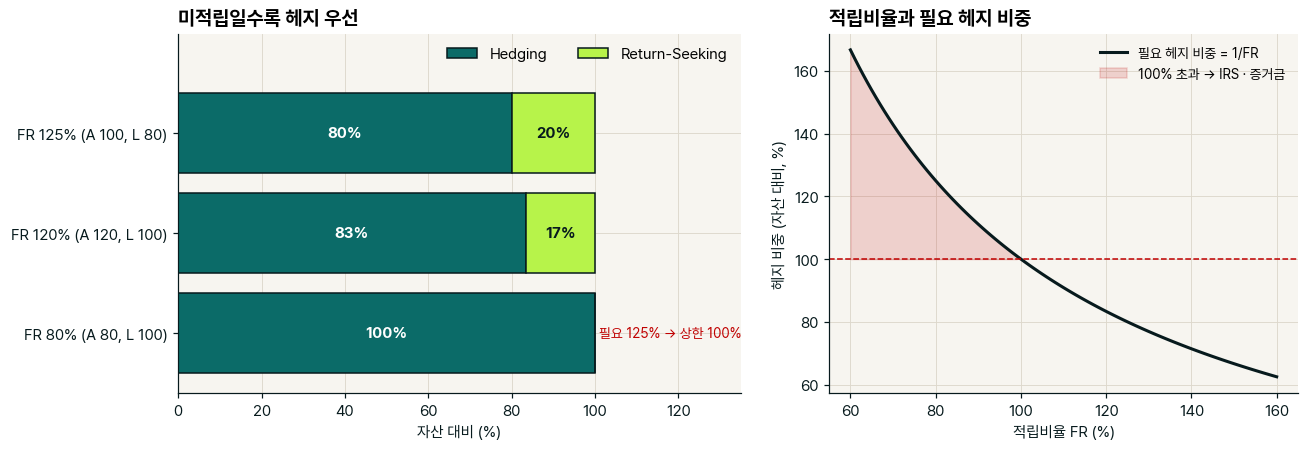

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.2, 1]})
labels = [c[0] for c in CASES][::-1]
hedge = [min(D_L * c[2] / (D_H * c[1]), 1) for c in CASES][::-1]
ax1.barh(labels, [h * 100 for h in hedge], color=TEAL, edgecolor=INK, label="Hedging")
ax1.barh(labels, [(1 - h) * 100 for h in hedge], left=[h * 100 for h in hedge], color=LIME, edgecolor=INK, label="Return-Seeking")
for i, h in enumerate(hedge):
    ax1.text(h * 50, i, f"{h:.0%}", ha="center", va="center", color="white", fontweight="bold")
    if h < 1: ax1.text(h * 100 + (1 - h) * 50, i, f"{1 - h:.0%}", ha="center", va="center", color=INK, fontweight="bold")
ax1.text(101, 0, "필요 125% → 상한 100%", va="center", color=RED, fontsize=9)
ax1.set_xlim(0, 135); ax1.set_ylim(-0.6, 3.0); ax1.set_xlabel("자산 대비 (%)"); ax1.legend(loc="upper right", ncol=2)
ax1.set_title("미적립일수록 헤지 우선")
frs = np.linspace(0.6, 1.6, 101)
ax2.plot(frs * 100, 100 / frs, color=INK, lw=2, label="필요 헤지 비중 = 1/FR")
ax2.fill_between(frs * 100, 100, 100 / frs, where=(100 / frs > 100), color=RED, alpha=0.15, label="100% 초과 → IRS · 증거금")
ax2.axhline(100, color=RED, lw=1, ls="--")
ax2.set_xlabel("적립비율 FR (%)"); ax2.set_ylabel("헤지 비중 (자산 대비, %)")
ax2.set_title("적립비율과 필요 헤지 비중"); ax2.legend(fontsize=9)
fig.tight_layout(); plt.show()

## 5. 51장 각주 확인 — FR 120%면 레버리지 없이, FR이 100% 아래면 오버레이
51장 각주: "앞 단원의 FR 120% 예는 헤지 83% + 수익 추구 17% = 100% — 레버리지 없이 된다. FR이 100% 아래면 헤지 몫(1/FR)이 100%를 넘어 그때 오버레이(레버리지)가 필요하다". 49장 그림(자산 대비 83% / 17%)과 같은 숫자인지 계산해 봅니다.

In [9]:
for A_, L_ in [(120, 100), (80, 100)]:
    need = D_L * L_ / (D_H * A_)
    over = max(need - 1, 0)
    print(f"FR {A_ / L_:.0%}: 헤지 몫 {need:.0%} · 수익 추구 {max(1 - need, 0):.0%} · 오버레이(레버리지) {over:.0%}")
need120 = D_L * 100 / (D_H * 120)
check("FR 120% 헤지 비중 (%)", 100 * need120, 83, 0.5, ".1f")
check("FR 120% 수익 추구 (%)", 100 * (1 - need120), 17, 0.5, ".1f")
check("FR 80% 필요 헤지 (%)", 100 * D_L * 100 / (D_H * 80), 125, 0.5, ".1f")

FR 120%: 헤지 몫 83% · 수익 추구 17% · 오버레이(레버리지) 0%
FR 80%: 헤지 몫 125% · 수익 추구 0% · 오버레이(레버리지) 25%
✓ FR 120% 헤지 비중 (%): 계산 83.3 · 강의 83.0 (허용 ±0.5)
✓ FR 120% 수익 추구 (%): 계산 16.7 · 강의 17.0 (허용 ±0.5)
✓ FR 80% 필요 헤지 (%): 계산 125.0 · 강의 125.0 (허용 ±0.5)


## 6. 정리
- **헤지 몫은 부채가 정한다** — 식에 μ도 γ도 없다. 성향을 이유로 헤지를 깎으면 그것은 금리 베팅.
- 수익 추구 몫은 남는 위험 예산이 정한다 — 헤지를 올리면 같은 주식 비중에서 잉여금 변동성이 12.8% → 7.5%.
- PSP 50 + LHP 80 = 130% → 모자란 30%를 고정금리 수취 스왑으로 채우는 순간 증거금 · 버퍼가 해의 일부가 된다 → 06 노트북.

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [10]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 19 / 19 통과


---
## 바꿔 보기 (연습 문제)

1. γ = 3.6 대신 2.0이면 PSP는? 합계가 몇 %가 되고 스왑은 얼마가 필요한가? 헤지 몫은 그대로인가?
2. 헤지 수단을 50년 국채(D_H = 30)로 바꾸면 FR 125%에서 필요한 헤지 비중은? 합계가 100% 안으로 들어오나?
3. 이사회가 잉여금 변동성 한도를 9%로 정했다. 헤지 19%와 100%에서 허용되는 최대 주식 비중을 각각 구하라(`surplus_vol(w_e, h) = 0.09`를 w_e로 풀기).

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [11]:
# 여기에 직접 해 보기

In [12]:
# 여기에 직접 해 보기

In [13]:
# 여기에 직접 해 보기